SBB Railway Efficiency  

In [46]:
import pandas as pd
import glob

files = glob.glob("Data/*.csv")

dfs = []

cols = [
    "BETRIEBSTAG",
    "BETREIBER_NAME",
    "PRODUKT_ID",
    "HALTESTELLEN_NAME",
    "ANKUNFTSZEIT",
    "AN_PROGNOSE"
]

for file in files:
    # load only needed columns
    df = pd.read_csv(file, sep=";", usecols=cols, low_memory=False)
    
    # assign year
    if "2019" in file:
        df["year"] = 2019
    elif "2020" in file:
        df["year"] = 2020
    elif "2026" in file:
        df["year"] = 2026
    
    dfs.append(df)

# combine all data
df = pd.concat(dfs, ignore_index=True)

In [47]:
df = df.rename(columns={
    "BETRIEBSTAG": "date",
    "BETREIBER_NAME": "operator",
    "PRODUKT_ID": "product",
    "HALTESTELLEN_NAME": "station",
    "ANKUNFTSZEIT": "scheduled_arrival",
    "AN_PROGNOSE": "actual_arrival"
})

In [48]:
df = df[df["product"] == "Zug"]

In [49]:
df["scheduled_arrival"] = pd.to_datetime(
    df["scheduled_arrival"], errors="coerce", dayfirst=True
)

df["actual_arrival"] = pd.to_datetime(
    df["actual_arrival"], errors="coerce", dayfirst=True
)

In [50]:
df = df.dropna(subset=["scheduled_arrival", "actual_arrival"])

In [51]:
df["arrival_delay"] = (
    df["actual_arrival"] - df["scheduled_arrival"]
).dt.total_seconds() / 60

In [52]:
df.head()

,date,operator,product,station,scheduled_arrival,actual_arrival,year,arrival_delay
99,15.03.2019,NeTS Planung DB,Zug,Schaffhausen,2019-03-15 05:54:00,2019-03-15 05:54:54,2019,0.900000
101,15.03.2019,NeTS Planung DB,Zug,Schaffhausen,2019-03-15 06:24:00,2019-03-15 06:25:17,2019,1.283333
103,15.03.2019,NeTS Planung DB,Zug,Schaffhausen,2019-03-15 06:54:00,2019-03-15 06:54:37,2019,0.616667
105,15.03.2019,NeTS Planung DB,Zug,Schaffhausen,2019-03-15 07:24:00,2019-03-15 07:25:15,2019,1.250000
107,15.03.2019,NeTS Planung DB,Zug,Schaffhausen,2019-03-15 07:54:00,2019-03-15 07:54:44,2019,0.733333


In [53]:
df = df[df["operator"].str.contains("SBB", na=False)]

In [58]:
foreign_keywords = [
    "Hbf", "Messe/Deutz", "Praha", "Hamburg", "Münster",
    "Osnabrück", "Darmstadt", "Bremen", "Dortmund", "Köln"
]

pattern = "|".join(foreign_keywords)
df_ch = df[~df["station"].str.contains(pattern, case=False, na=False)]

In [59]:
df.head()

,date,operator,product,station,scheduled_arrival,actual_arrival,year,arrival_delay,is_delayed,hour
372,15.03.2019,Schweizerische Bundesbahnen SBB,Zug,Chiasso,2019-03-15 19:10:00,2019-03-15 19:09:19,2019,-0.683333,False,19
373,15.03.2019,Schweizerische Bundesbahnen SBB,Zug,Lugano,2019-03-15 19:38:00,2019-03-15 19:49:05,2019,11.083333,True,19
374,15.03.2019,Schweizerische Bundesbahnen SBB,Zug,Bellinzona,2019-03-15 20:10:00,2019-03-15 20:14:24,2019,4.400000,True,20
375,15.03.2019,Schweizerische Bundesbahnen SBB,Zug,Arth-Goldau,2019-03-15 21:09:00,2019-03-15 21:09:57,2019,0.950000,False,21
376,15.03.2019,Schweizerische Bundesbahnen SBB,Zug,Zug,2019-03-15 21:27:00,2019-03-15 21:28:23,2019,1.383333,False,21


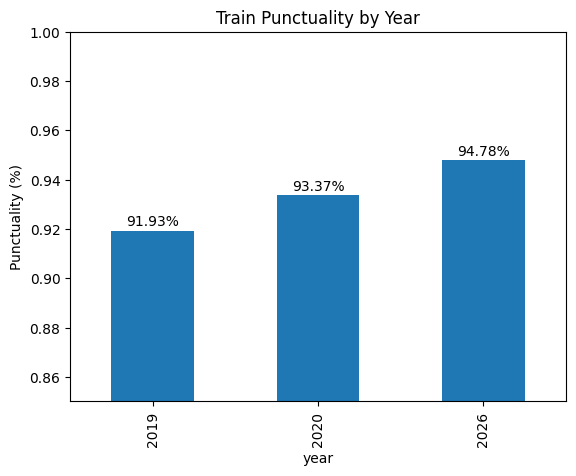

In [60]:
import matplotlib.pyplot as plt

df["is_delayed"] = df["arrival_delay"] > 3

punctuality = 1 - df.groupby("year")["is_delayed"].mean()

ax = punctuality.plot(kind="bar", title="Train Punctuality by Year")

plt.ylim(0.85, 1.0)
plt.ylabel("Punctuality (%)")

for i, v in enumerate(punctuality):
    plt.text(i, v + 0.002, f"{v:.2%}", ha='center')


plt.show()

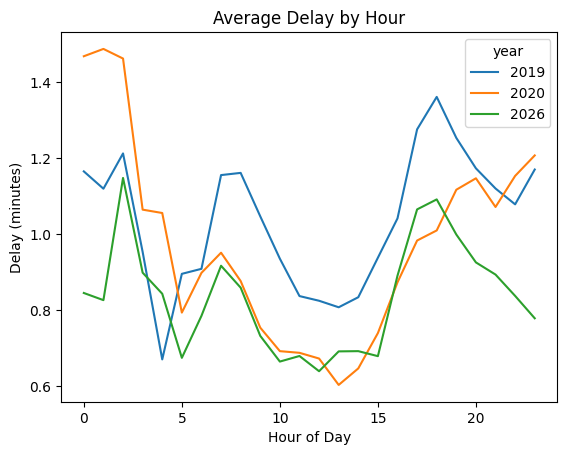

In [61]:
df["hour"] = df["scheduled_arrival"].dt.hour

hourly_delay = df.groupby(["year", "hour"])["arrival_delay"].mean().unstack()

hourly_delay.T.plot(title="Average Delay by Hour")

plt.ylabel("Delay (minutes)")
plt.xlabel("Hour of Day")

plt.show()

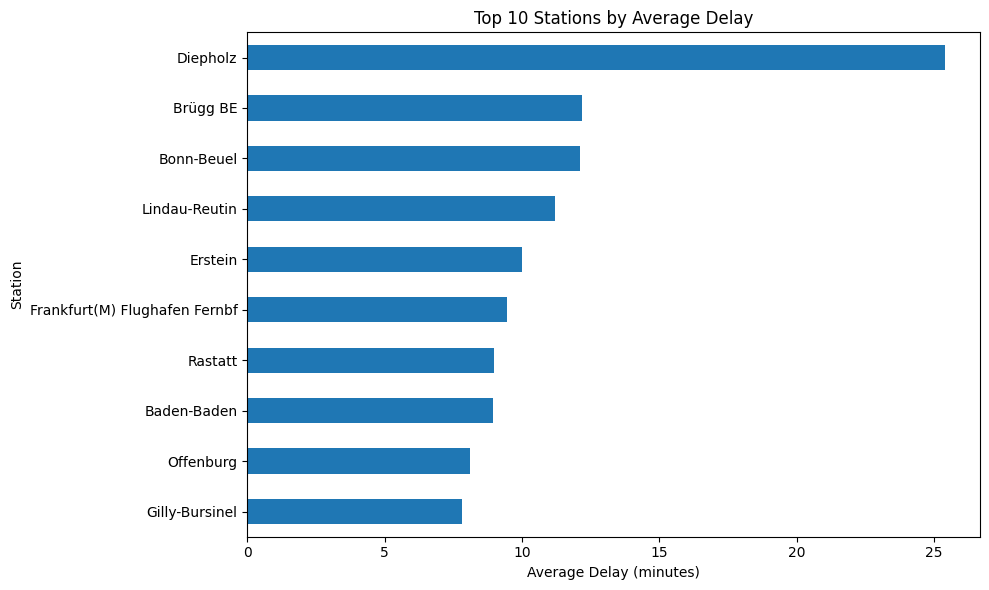

In [64]:

foreign_keywords = [
    "Hbf", "Messe/Deutz", "Praha", "Hamburg", "Münster",
    "Osnabrück", "Darmstadt", "Bremen", "Dortmund", "Köln"
]

pattern = "|".join(foreign_keywords)
df_ch = df[~df["station"].str.contains(pattern, case=False, na=False)]
import matplotlib.pyplot as plt

top_delayed = (
    df.groupby("station")["arrival_delay"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
top_delayed.sort_values().plot(kind="barh")
plt.title("Top 10 Stations by Average Delay")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

In [29]:
df["station"].value_counts().head(10)

station
Zürich HB             19657
Zürich Oerlikon       11400
Zürich Stadelhofen     8980
Zürich Hardbrücke      8720
Olten                  7163
Winterthur             6173
Lausanne               5920
Genève                 5440
Zürich Altstetten      5172
Basel SBB              5142
Name: count, dtype: int64

In [30]:
df.groupby("year")["is_delayed"].mean()

year
2019    0.080692
2020    0.066259
2026    0.052173
Name: is_delayed, dtype: float64

In [31]:
df.groupby(["year","hour"])["is_delayed"].mean()

year  hour
2019  0       0.125664
      1       0.107036
      2       0.117737
      3       0.097600
      4       0.025641
                ...   
2026  19      0.061076
      20      0.063678
      21      0.057650
      22      0.053007
      23      0.057319
Name: is_delayed, Length: 72, dtype: float64

In [32]:
df.groupby("date")["arrival_delay"].mean()

date
13.03.2020    1.289527
13.03.2026    0.882081
14.03.2020    0.681264
14.03.2026    0.935383
15.03.2019    1.420734
15.03.2020    0.659362
15.03.2026    0.624493
16.03.2019    0.748034
16.03.2020    0.954039
16.03.2026    0.810329
17.03.2019    0.831438
17.03.2026    0.849631
18.03.2019    1.152477
Name: arrival_delay, dtype: float64

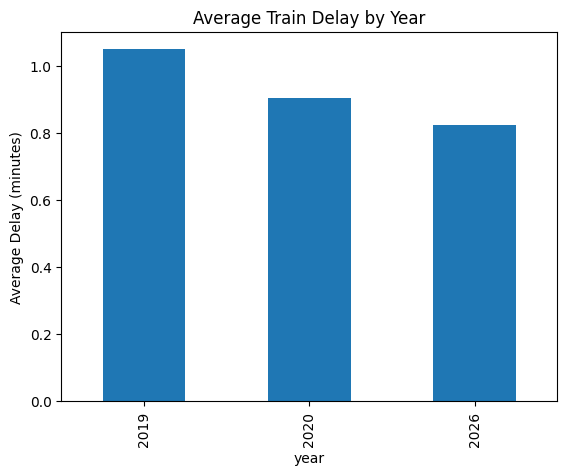

In [44]:
import matplotlib.pyplot as plt

avg_delay = df.groupby("year")["arrival_delay"].mean()

ax = avg_delay.plot(kind="bar", title="Average Train Delay by Year")

plt.ylabel("Average Delay (minutes)")


plt.show()

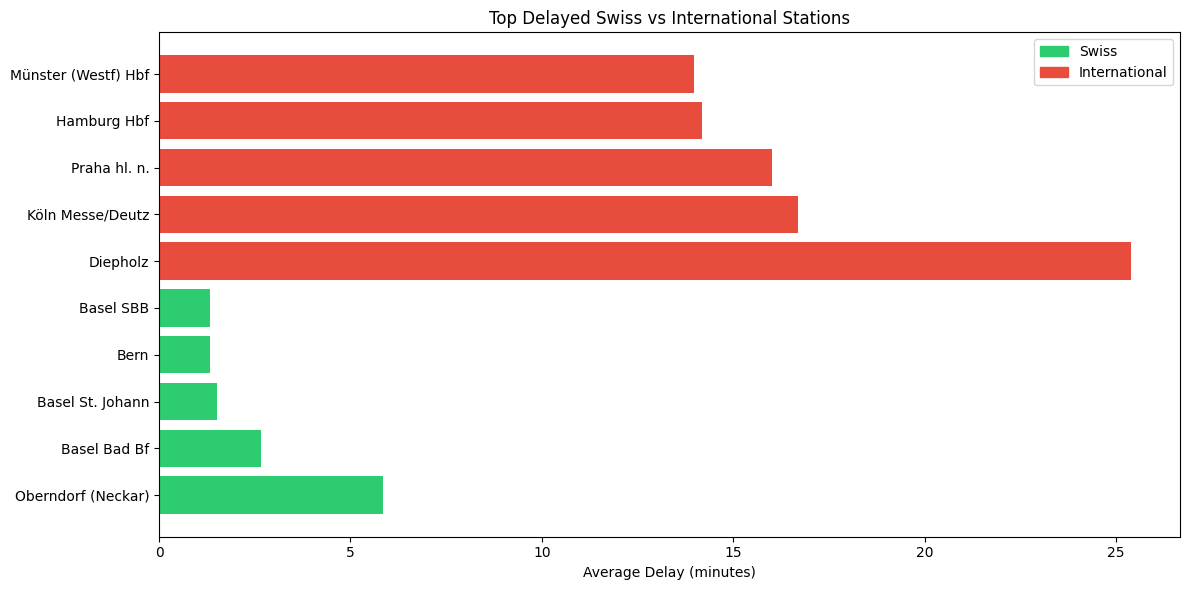

In [68]:
df["is_swiss_station"] = df["station"].str.contains(pattern, case=False, na=False)

# Top 5 Swiss stations
top_swiss = (
    df[df["is_swiss_station"]]
    .groupby("station")["arrival_delay"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

# Top 5 International stations
top_int = (
    df[~df["is_swiss_station"]]
    .groupby("station")["arrival_delay"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

top_swiss_df = top_swiss.reset_index()
top_swiss_df["type"] = "Swiss"

top_int_df = top_int.reset_index()
top_int_df["type"] = "International"

combined = pd.concat([top_swiss_df, top_int_df])

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

colors = combined["type"].map({
    "Swiss": "#2ecc71",
    "International": "#e74c3c"
})

plt.barh(combined["station"], combined["arrival_delay"], color=colors)

plt.xlabel("Average Delay (minutes)")
plt.title("Top Delayed Swiss vs International Stations")

# Legend
import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color='#2ecc71', label='Swiss')
red_patch = mpatches.Patch(color='#e74c3c', label='International')
plt.legend(handles=[green_patch, red_patch])

plt.tight_layout()
plt.show()